# Lensing growth factor $D_L(z)$

In cosmology, gravitational lensing of light from distant galaxies depends on the **growth of structure** and the **geometry of the Universe**.

We define the growth factor of lensing $D_L(z)$, used in weak lensing observables such as the convergence power spectrum.

This notebook derives and evaluates:

$
D_L(z) = \frac{3}{2} \Omega_m \int_0^z dz' \, \frac{D(z')}{E(z')} \cdot \frac{x(z') \left[ x(z) - x(z') \right]}{x(z)} (1 + z')$

where:
- $\Omega_m$ is the matter density today,
- $x(z)$ is the comoving distance,
- $E(z) = H(z)/H_0$ is the normalized Hubble rate,
- $D(z)$ is the linear growth factor normalized to $D(0) = 1$.


In [3]:
# general imports
import numpy as np
from scipy.integrate import quad
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# astropy imports
from astropy.cosmology import Planck18 as cosmo
# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations


### 1. Solve using approximations and numerical integration

First, we solve the integral manually using `astropy` for the background quantities, assuming that the growth factor of matter can be approximated as,


$D(z) = \frac{\int_0^a \frac{da'}{a'^3 E(a')^3}}{\int_0^1 \frac{da'}{a'^3 E(a')^3}}, \quad \text{with } a = \frac{1}{1+z}$


In [10]:

# Precompute D(z) and cache with interpolation
z_cache = np.linspace(0, 1000, 1000)

def compute_D_growth(z_vals):
    norm, _ = quad(lambda a: 1 / (a * cosmo.efunc(1/a - 1))**3, 0, 1)
    D_list = []
    for z in z_vals:
        a = 1 / (1 + z)
        growth, _ = quad(lambda a_: 1 / (a_ * cosmo.efunc(1/a_ - 1))**3, 0, a)
        D_list.append(growth / norm)
    return np.array(D_list)

D_vals = compute_D_growth(z_cache)
D_interp = interp1d(z_cache, D_vals, kind='cubic', bounds_error=False, fill_value=0.0)

# Cache comoving distance interpolation
x_cache = cosmo.comoving_transverse_distance(z_cache).value  # in Mpc
x_interp = interp1d(z_cache, x_cache, kind='cubic', bounds_error=False, fill_value=0.0)

# Optimized lensing efficiency integrand using interpolants
def D_L_integrand(zp, z):
    x_z = x_interp(z)
    x_zp = x_interp(zp)
    x_zp_z = x_z - x_zp
    if x_zp_z < 0:
        return 0
    D_zp = D_interp(zp)
    E_zp = cosmo.efunc(zp)
    return D_zp * x_zp * x_zp_z / x_z * (1 + zp) / E_zp

# Lensing efficiency D_L(z)
def D_L(z):
    Omega_m = cosmo.Om0
    integral, _ = quad(D_L_integrand, 0, z, args=(z,))
    return 1.5 * Omega_m * integral


In [30]:
# Evaluate
z_vals = np.logspace(-2, 3, 100)
D_L_vals = [D_L(z) for z in z_vals]

### 2. Solve using `cloelib` and numerical integration

In [33]:
# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=cosmo.H0.value, 
                            Omega_cdm0=cosmo.Om0 - cosmo.Ob0, 
                            Omega_b0=cosmo.Ob0, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, z_vals)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, z_vals, log10TAGN=7.8)

In [63]:
# Re-evaluate the intagrand using CAMB and HMcode
def D_L_integrand_cloelib(zp, z):
    x_z = background.transverse_comoving_distance(z)
    x_zp = background.transverse_comoving_distance(zp)
    x_zp_z = x_z - x_zp
    if x_zp_z < 0:
        return 0
    D_zp = linear_perturbations_emu.growth_factor(zp, 0.01) #fix k-dependency
    E_zp = background.hubble_parameter(zp)/background.hubble_parameter(0)
    return D_zp * x_zp * x_zp_z / x_z * (1 + zp) / E_zp

# Lensing efficiency D_L(z)
def D_L_cloelib(z):
    Omega_m = background.Omega_m(0)
    integral, _ = quad(D_L_integrand_cloelib, 0, z, args=(z,))
    return 1.5 * Omega_m * integral

In [64]:
# Evaluate
D_L_vals_cloelib = [D_L_cloelib(z) for z in z_vals]

/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_78070/2865893310.py:15: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(D_L_integrand_cloelib, 0, z, args=(z,))
/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_78070/2865893310.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, _ = quad(D_L_integrand_cloelib, 0, z, args=(z,))


### Plot both quantities

In [76]:
colors = {
    'astropy': 'cornflowerblue',
    'cloelib': 'mediumorchid'
}

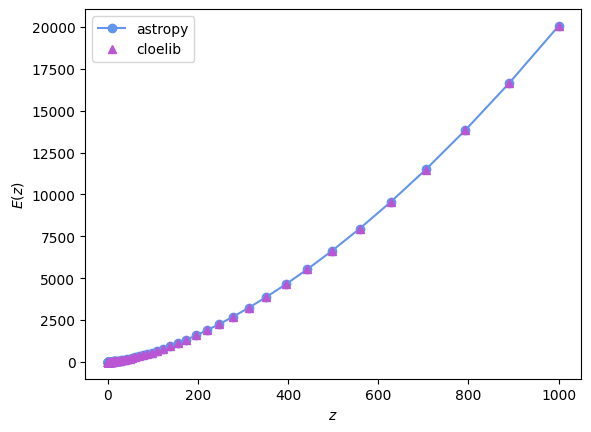

In [78]:
plt.plot(z_vals, cosmo.efunc(z_vals), 'o-', label='astropy', color=colors['astropy'])
plt.plot(z_vals, background.hubble_parameter(z_vals)/background.hubble_parameter(0), '^', label='cloelib', color=colors['cloelib'])
plt.xlabel('$z$')
plt.ylabel(r'$E(z)$')
plt.legend();

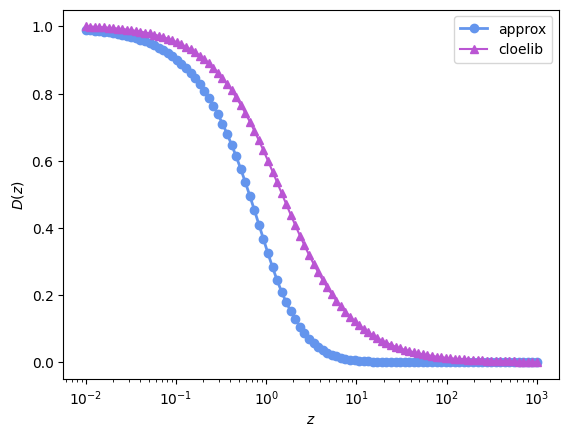

In [79]:
plt.semilogx(z_vals, D_interp(z_vals), 'o-', label='approx', linewidth=2, color=colors['astropy'])
plt.semilogx(z_vals, nonlinear_perturbations_emu.growth_factor(z_vals, 0.01), '^-', label='cloelib', color=colors['cloelib'])
plt.xlabel('$z$')
plt.ylabel(r'$D(z)$')
plt.legend();

/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_78070/136326172.py:3: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val2 = quad(D_L_integrand_cloelib, 0, z, args=(z,))[0]
/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_78070/136326172.py:3: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val2 = quad(D_L_integrand_cloelib, 0, z, args=(z,))[0]


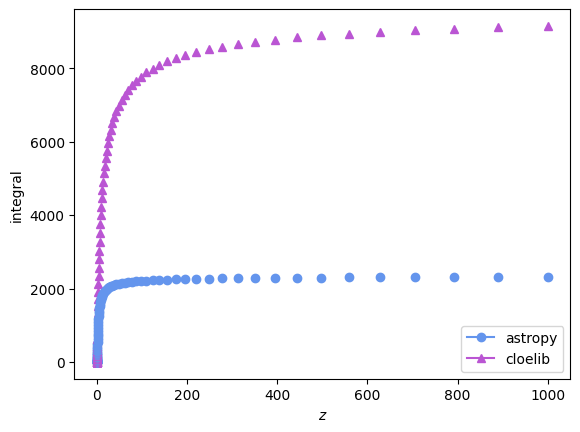

In [80]:
for z in z_vals:
    val1 = quad(D_L_integrand, 0, z, args=(z,))[0]
    val2 = quad(D_L_integrand_cloelib, 0, z, args=(z,))[0]
    
    plt.plot(z, val1, 'o-', color=colors['astropy'], label='astropy' if z == z_vals[0] else "")
    plt.plot(z, val2, '^-', color=colors['cloelib'], label='cloelib' if z == z_vals[0] else "")

plt.xlabel('$z$')
plt.ylabel(r'integral')
plt.legend()
plt.show()

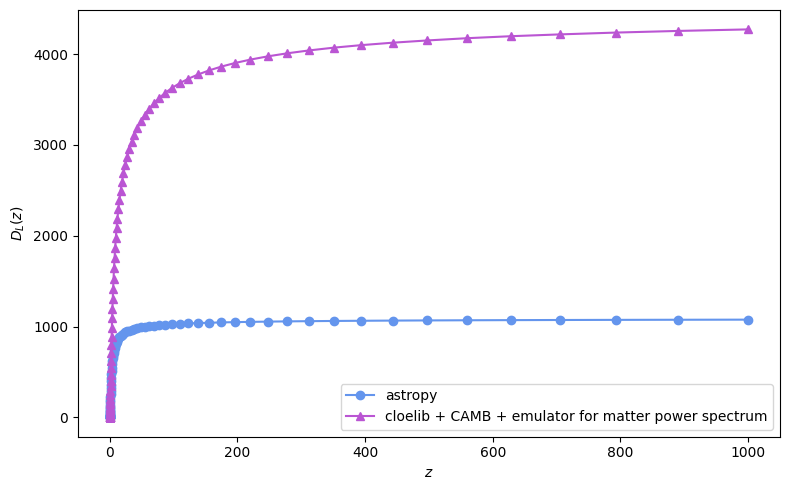

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(z_vals, D_L_vals, 'o-', label='astropy', color=colors['astropy'])
plt.plot(z_vals, D_L_vals_cloelib, '^-', label='cloelib + CAMB + emulator for matter power spectrum', color=colors['cloelib'])
plt.xlabel('$z$')
plt.ylabel(r'$D_L(z)$')
plt.tight_layout()
plt.legend();
plt.show()